In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
plt.rc('font',family='Arial')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 9

import time
start_time = time.time()
print(time.ctime())

import warnings
warnings.filterwarnings('ignore')

from dynamic_stock_model import DynamicStockModel

file_path = r'C:\Users\xmuxi\Desktop\2-UCAS\4-Co-Ni-Cu\Data\Sector_Vehicle\5Regions\\'

Sun Aug  2 15:33:37 2026


In [2]:
Regions = ['China','Japan','EU','USA','RoW']
Region_Colors = ['#D62728','#2CA02C','#FF7F0E','#1F77B4','#7F7F7F']

Powertrain_Scenarios = ['STEPS','APS','NZES']
Powertrains = ['ICEV','HEV','PHEV','BEV','FCV']
EV_List = ['PHEV','BEV']

Segment_Scenarios = ['Baseline'] #'Smaller', 'Larger'
Segments = ['AB','C','DE','SUV']
Segment_Colors = ['#1F77B4','#FF7F0E','#2CA02C','#D62728']

Battery_Sizes = ['Larger']  # 'Constant'
Battery_Scenarios = ['Baseline','NMC', 'NMA', 'LFP/LMFP', 'Na-ion','Optimized']

Cathodes =['LFP','LMFP','LNO','LMO','LNMO',
           'NCA-85','NCA-90','NCA-92','NCA-95','NMCA',
           'NMC-111','NMC-532','NMC-622','NMC-721','NMC-811','NMC-955',
           'LMR-NMC','Na-ion']

cathode_color_dict = {'LFP': '#7F7F7F',
                      'LMFP':'#BFBFBF',

                      'LNO':'#A7D3D4',
                      'LMO':'#42B7B9',
                      'LNMO':'#009B9E',
                      
                      'NCA-85':'#FFE285',
                      'NCA-90':'#FFD757',
                      'NCA-92':'#FFC611',
                      'NCA-95':'#E2AC00',
                      
                      'NMCA':'#7654A3',
                      
                      'NMC-111':'#C7F2FF',
                      'NMC-532':'#8FE4FF',
                      'NMC-622':'#56D7FF',
                      'NMC-721':'#00AEE5',
                      'NMC-811':'#0082AC',
                      'NMC-955':'#005772',
                      
                      'LMR-NMC':'#002060',
                      'Na-ion':'#F03B20'}
Cathode_Colors = [cathode_color_dict[ca] for ca in Cathodes]

#Component_Scenarios = ['Constant','Lighter']

Lifetime_Scenarios = ['Constant','Longer']

Materials = ['Copper','Nickel','Cobalt']

## Indicators
- Population (million persons)

In [3]:
df_pop = pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='Population', index_col=[0], header=3)
df_pop = df_pop.T
#df_pop = df_pop.loc[1950:,:]
df_pop = df_pop[Regions]
df_pop.head(2)

Region,China,Japan,EU,USA,RoW
1900,400.265000,44.103,278.2490,76.391,527.86193
1901,402.520077,44.662,280.5497,77.888,532.84672


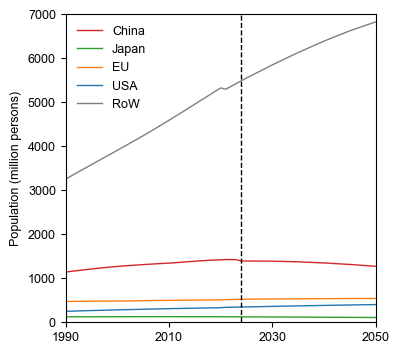

In [4]:
def plot_population(df):
    
    year_min = 1990
    df = df.loc[year_min:,:]
    
    fig, ax = plt.subplots(1,1, figsize=(4,4))
    
    for i, region in enumerate(Regions):
        ax.plot(df.index, df[region], label=region, color=Region_Colors[i], lw=1)
        
    ax.set_xlim(year_min,2050)
    ax.set_xticks(np.arange(year_min,2051,20))
    ax.set_ylim(0,7000)
    ax.set_ylabel('Population (million persons)')
    ax.axvline(x=2024, color="black", linestyle="--", lw=1)
    ax.legend(frameon=False)
    plt.savefig(file_path + 'Population.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()   
    
    
plot_population(df_pop)

## Layer: Vehicle
- PEV owenership (vehicles per 1000 person)

In [5]:
df_ownership = pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='PEV_Ownership', index_col=[0], header=3)
df_ownership = df_ownership.T
#df_ownership = df_ownership.loc[1950:,:]
df_ownership.head(2)

Region,China,Japan,EU,USA,RoW
1900,0.000000,0.000000,0.000000,0.000000,0.000000
1901,0.000636,0.678954,1.334893,4.294128,0.084382


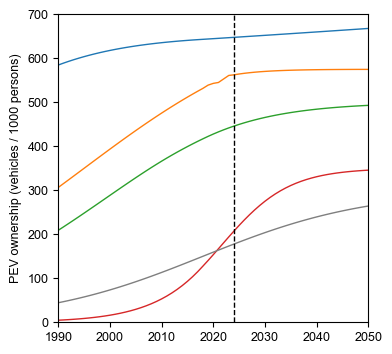

In [6]:
def plot_ownership(df):
    
    year_min = 1990
    df = df.loc[year_min:,:]
    
    fig, ax = plt.subplots(1,1, figsize=(4,4))
    
    for i, region in enumerate(Regions):
        ax.plot(df.index, df[region], label=region, color=Region_Colors[i], lw=1)
        
    ax.set_xlim(year_min,2050)
    ax.set_xticks(np.arange(year_min,2051,10))
    ax.set_ylim(0,700)
    ax.axvline(x=2024, color="black", linestyle="--", lw=1)
    ax.set_ylabel('PEV ownership (vehicles / 1000 persons)')
    #ax.legend(frameon=False)
    plt.savefig(file_path + 'PEV_Ownership.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()   
    
    
plot_ownership(df_ownership)

- Lifetime

In [7]:
df_vehicle_lifetime =  pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='Vehicle_Lifetime', index_col=[0,1], header=3)
df_vehicle_lifetime = df_vehicle_lifetime.T
#df_vehicle_lifetime = df_vehicle_lifetime.loc[1950:,:]
df_vehicle_lifetime.head(2)

Scenario Constant                         Longer                        
Region      China Japan    EU   USA   RoW  China Japan    EU   USA   RoW
1900         14.5  13.3  14.4  16.2  16.0   14.5  13.3  14.4  16.2  16.0
1901         14.5  13.3  14.4  16.2  16.0   14.5  13.3  14.4  16.2  16.0

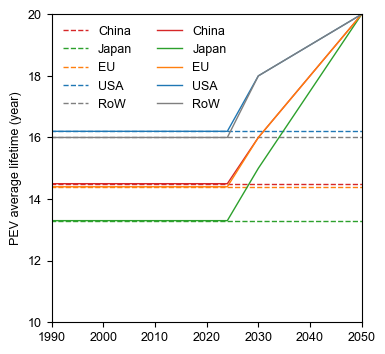

In [8]:
def plot_lifetime(df):
    year_min = 1990
    fig, ax = plt.subplots(1,1, figsize=(4,4))
    
    for j, region in enumerate(Regions):
        ax.plot(df.index, df['Constant',region], label=region, color=Region_Colors[j], lw=1, linestyle='--')
    for j, region in enumerate(Regions):
        ax.plot(df.index, df['Longer',region], label=region, color=Region_Colors[j], lw=1)
    
    ax.set_xlim(year_min,2050)
    ax.set_xticks(np.arange(year_min,2051,10))
    ax.set_ylim(10,20)
    ax.set_ylabel('PEV average lifetime (year)')
    ax.legend(frameon=False, ncol=2)
    plt.savefig(file_path + 'PEV_Lifetime.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
    
    
plot_lifetime(df_vehicle_lifetime)

In [9]:
def cal_vehicle_stock_flow_raw(df_p, df_owner, df_lt):
    
    df_stock = pd.DataFrame(index=df_owner.index, 
                            columns=pd.MultiIndex.from_product([Regions,Lifetime_Scenarios], 
                                                               names=['Region','Lifetime']))
    df_inflow = df_stock.copy()
    
    for r in Regions:
        for lt in Lifetime_Scenarios:
            ## million person * vehicle/1000person  --------  * 1000  ==== vehicles
            df_stock[(r,lt)] = df_p[r] * df_owner[r] * 1000
            ## stock-driven
            DSM = DynamicStockModel(t = list(df_stock.index), 
                                    s = list(df_stock[(r,lt)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,r)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,r)])})
            DSM.compute_stock_driven_model()
            DSM.compute_outflow_total()
            ## fill in
            df_inflow[(r,lt)] = DSM.i
            
    return df_inflow, df_stock


## Unit: vehicles
df_vehicle_inflow_raw, df_vehicle_stock_raw = cal_vehicle_stock_flow_raw(df_pop, df_ownership, df_vehicle_lifetime)
df_vehicle_inflow_raw.head(2)

Region         China                     Japan                           EU  \
Lifetime    Constant      Longer      Constant        Longer       Constant   
1900        0.000000    0.000000      0.000000      0.000000       0.000000   
1901      255.939564  255.939564  30336.450633  30336.450633  374664.446469   

Region                             USA                          RoW  \
Lifetime         Longer       Constant         Longer      Constant   
1900           0.000000       0.000000       0.000000      0.000000   
1901      374664.446469  334604.602464  334604.602464  44981.845191   

Region                  
Lifetime        Longer  
1900          0.000000  
1901      44981.845191

- Powertrain marketshare

In [10]:
df_powertrain_share = pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='PEV_Powertrain', index_col=[0,1,2], header=3)
df_powertrain_share = df_powertrain_share.T
#df_powertrain_share = df_powertrain_share.loc[1950:,:]
df_powertrain_share.fillna(value=0, inplace=True)
df_powertrain_share.head(2)

Scenario   STEPS                                                ... NZES       \
Region     China                     Japan                      ...  USA        
Powertrain  ICEV  HEV PHEV  BEV  FCV  ICEV  HEV PHEV  BEV  FCV  ... ICEV  HEV   
1900         1.0  0.0  0.0  0.0  0.0   1.0  0.0  0.0  0.0  0.0  ...  1.0  0.0   
1901         1.0  0.0  0.0  0.0  0.0   1.0  0.0  0.0  0.0  0.0  ...  1.0  0.0   

Scenario                                            
Region                     RoW                      
Powertrain PHEV  BEV  FCV ICEV  HEV PHEV  BEV  FCV  
1900        0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  
1901        0.0  0.0  0.0  1.0  0.0  0.0  0.0  0.0  

[2 rows x 75 columns]

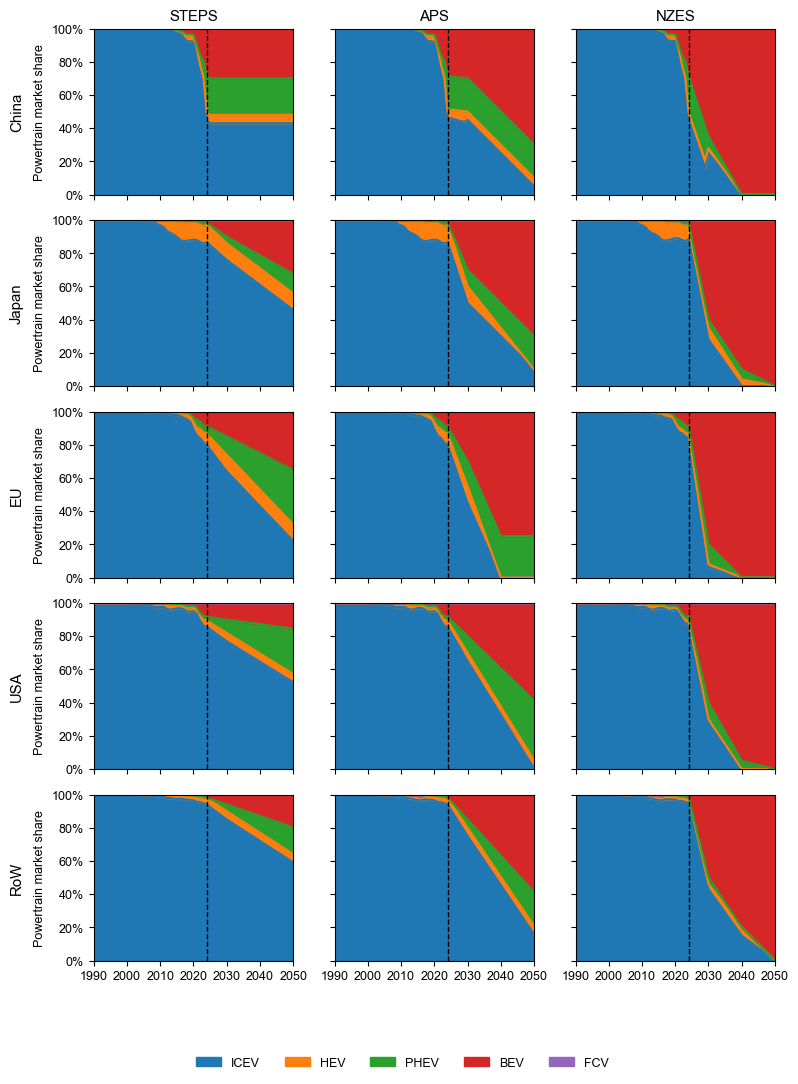

In [11]:
def plot_powertrain_share(df):
    year_min=1990
    df = df.loc[year_min:,:]
    
    fig, axes = plt.subplots(5,3, figsize=(8,10), sharex=True, sharey=True)
    
    for i, region in enumerate(Regions):
        for j, sce in enumerate(Powertrain_Scenarios):
        
            df[sce,region].plot.area(ax=axes[i,j], y=Powertrains, legend=False)
            
            if i == 0:
                axes[i,j].set_title(sce)
            if j == 0:
                axes[i,j].set_ylabel('Powertrain market share')
                axes[i, j].annotate(region, xy=(-0.35, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
                
            axes[i,j].set_xlim(year_min,2050)
            axes[i,j].axvline(x=2024, color="black", linestyle="--", lw=1)
            axes[i,j].set_xticks(np.arange(year_min,2051,10))
            axes[i,j].set_ylim(0,1)
            #设置纵坐标为百分数
            axes[i,j].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
        
    #为最后一个子图添加 legend
    handles, labels = axes[-1,-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, -0.05), frameon=False)
    plt.savefig(file_path + 'PEV_Powertrain_Share.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.tight_layout()
    plt.show()
    
    
plot_powertrain_share(df_powertrain_share)

- Segment marketshare

In [12]:
df_segment_share  = pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='PEV_Segment', index_col=[0,1,2], header=3)
df_segment_share = df_segment_share.T
#df_segment_share = df_segment_share.loc[1950:,:]
df_segment_share.fillna(value=0, inplace=True)
df_segment_share.head(2)

Scenario Baseline                                                        ...  \
Region      China                   Japan                      EU        ...   
Segment        AB     C    DE   SUV    AB     C    DE   SUV    AB     C  ...   
1900         0.34  0.26  0.22  0.18  0.55  0.15  0.22  0.08  0.34  0.32  ...   
1901         0.34  0.26  0.22  0.18  0.55  0.15  0.22  0.08  0.34  0.32  ...   

Scenario Larger                                                      
Region       EU        USA                    RoW                    
Segment      DE   SUV   AB     C    DE  SUV    AB     C    DE   SUV  
1900       0.25  0.09  0.1  0.27  0.43  0.2  0.26  0.24  0.36  0.14  
1901       0.25  0.09  0.1  0.27  0.43  0.2  0.26  0.24  0.36  0.14  

[2 rows x 60 columns]

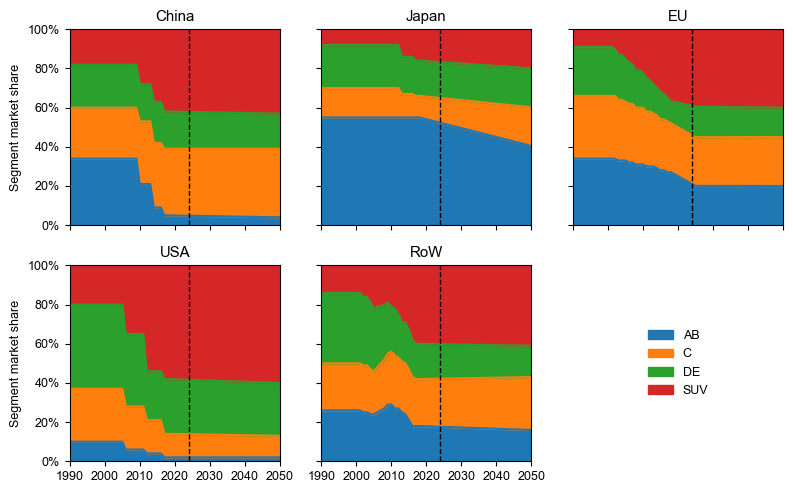

In [13]:
def plot_segment_share(df, seg_sce):
    year_min=1990
    df = df.loc[year_min:,:]
    
    fig, [[ax1,ax2,ax3],[ax4,ax5,ax6]] = plt.subplots(2,3, figsize=(8,5), sharex=True, sharey=True)
    axes = [ax1,ax2,ax3,ax4,ax5,ax6]

    for i, region in enumerate(Regions):
        
        df[seg_sce,region].plot.area(ax=axes[i], y=Segments, legend=False)

        axes[i].set_title(region)
        axes[i].set_ylabel('Segment market share')

        axes[i].set_xlim(year_min,2050)
        axes[i].set_xticks(np.arange(year_min,2051,10))
        axes[i].set_ylim(0,1)
        #设置纵坐标为百分数
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
        axes[i].axvline(x=2024, color="black", linestyle="--", lw=1)
        
     # 将倒数第二个子图的图例添加到最后一个子图
    handles, labels = axes[-2].get_legend_handles_labels()
    axes[-1].legend(handles, labels, loc='center', frameon=False)
    # 隐藏最后一个子图的框线
    axes[-1].axis('off')
    plt.savefig(file_path + 'PEV_Segment_Share_'+seg_sce+'.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.tight_layout()
    plt.show()
    
    
#plot_segment_share(df_segment_share, 'Smaller')
plot_segment_share(df_segment_share, 'Baseline')

In [14]:
%%time

def cal_vehicle_stock_flow_split(df_i, df_power, df_seg, df_lt):
    
    df_inflow = pd.DataFrame(index=df_i.index, 
                             columns=pd.MultiIndex.from_product([Regions,Powertrain_Scenarios,Powertrains,Segment_Scenarios,Segments,Lifetime_Scenarios],
                                                                names=['Region','Powertrain Scenario','Powertrain','Segment Scenario','Segment','Lifetime']))
    df_stock = df_inflow.copy()
    df_outflow = df_inflow.copy()
    
    for r in Regions:
        for p_sce in Powertrain_Scenarios:
            for p in Powertrains:
                for s_sce in Segment_Scenarios:
                    for s in Segments:
                        for lt in Lifetime_Scenarios:
                            df_inflow[(r,p_sce,p,s_sce,s,lt)] = df_i[(r,lt)] * df_power[(p_sce,r,p)] * df_seg[(s_sce,r,s)]
                            ## inflow-driven
                            DSM = DynamicStockModel(t = list(df_inflow.index), 
                                                    i = list(df_inflow[(r,p_sce,p,s_sce,s,lt)]),
                                                    lt = {'Type': 'Normal',
                                                          'Mean': list(df_lt[(lt,r)]),    
                                                          'StdDev': list(0.3 * df_lt[(lt,r)])})
                            DSM.compute_s_c_inflow_driven()
                            DSM.compute_stock_total()
                            DSM.compute_o_c_from_s_c()
                            DSM.compute_outflow_total()
                            ## fill in
                            df_stock[(r,p_sce,p,s_sce,s,lt)] = DSM.s
                            df_outflow[(r,p_sce,p,s_sce,s,lt)] = DSM.o
                                
    return df_inflow, df_outflow, df_stock


## Unit: vehicles
df_vehicle_inflow, df_vehicle_outflow, df_vehicle_stock = cal_vehicle_stock_flow_split(df_vehicle_inflow_raw, df_powertrain_share, df_segment_share, df_vehicle_lifetime)
df_vehicle_inflow.head(2)

CPU times: total: 8.02 s
Wall time: 8.33 s


Region                   China                                              \
Powertrain Scenario      STEPS                                               
Powertrain                ICEV                                               
Segment Scenario      Baseline                                               
Segment                     AB                     C                    DE   
Lifetime              Constant     Longer   Constant     Longer   Constant   
1900                  0.000000   0.000000   0.000000   0.000000   0.000000   
1901                 87.019452  87.019452  66.544287  66.544287  56.306704   

Region                                                                ...  \
Powertrain Scenario                                                   ...   
Powertrain                                                HEV         ...   
Segment Scenario                                     Baseline         ...   
Segment                               SUV                  AB         ...   
Lifetime                Longer   Constant     Longer Constant Longer  ...   
1900                  0.000000   0.000000   0.000000      0.0    0.0  ...   
1901                 56.306704  46.069122  46.069122      0.0    0.0  ...   

Region                   RoW                                                  \
Powertrain Scenario     NZES                                                   
Powertrain               BEV             FCV                                   
Segment Scenario    Baseline        Baseline                                   
Segment                  SUV              AB               C              DE   
Lifetime            Constant Longer Constant Longer Constant Longer Constant   
1900                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   
1901                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   

Region                                      
Powertrain Scenario                         
Powertrain                                  
Segment Scenario                            
Segment                         SUV         
Lifetime            Longer Constant Longer  
1900                   0.0      0.0    0.0  
1901                   0.0      0.0    0.0  

[2 rows x 600 columns]

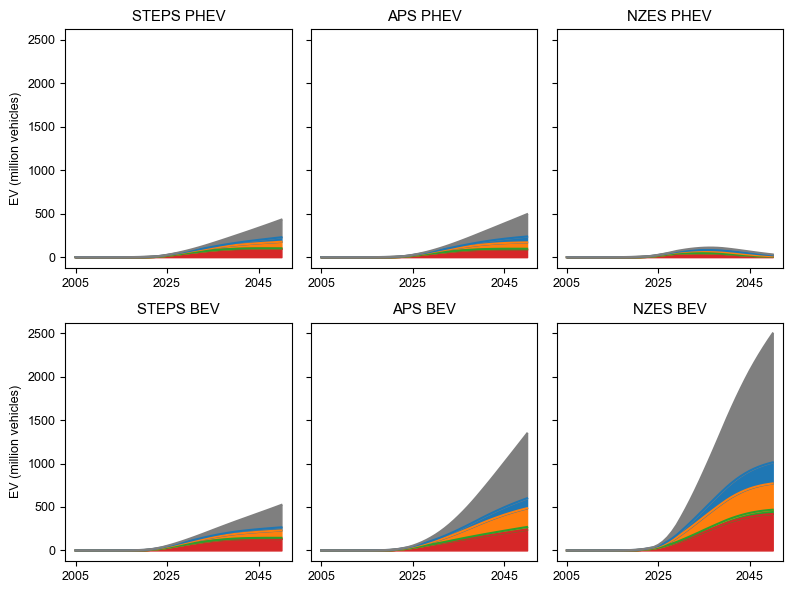

In [15]:
def plot_ev_stock(df):
    
    df = df.copy()
    df = df.T
    df.reset_index(inplace=True, drop=False)
    df = df[df.Powertrain.isin(['PHEV','BEV'])]
    df = df[df['Segment Scenario'] == 'Baseline']
    df = df[df.Lifetime=='Constant']
    df = df.groupby(['Powertrain Scenario','Powertrain', 'Region']).sum().T
    df = df.loc[2005:,:]
    
    df = df/ 1e6  ## from vehicle to million vehicles
    
    fig, axes = plt.subplots(2, 3, figsize = (8, 6), sharey=True)
    
    for i, ev in enumerate(['PHEV','BEV']):
        for j, p_sce in enumerate(Powertrain_Scenarios):
            
            df_ev = df[(p_sce,ev)]
            df_ev.plot.area(ax=axes[i,j], y=Regions, color=Region_Colors, legend=False)

            #axes[i,j].set_xlim(2005,2050)
            #axes[i,j].set_xticks(np.arange(2010,2051,10))
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylabel('EV (million vehicles)')
            axes[i,j].set_title(p_sce+ ' ' + ev)
            
    plt.tight_layout()
    plt.show()

    
plot_ev_stock(df_vehicle_stock)

## Layer Battery
- battery capacity (kWh/vehicle)

In [16]:
df_battery_capacity = pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='Battery_Capacity_New', index_col=[0,1,2,3], header=3)
df_battery_capacity = df_battery_capacity.T
df_battery_capacity.head(2)

Scenario     Constant                                                         \
Region          China                                                          
Powertrain       PHEV                                         BEV              
Segment            AB          C         DE        SUV         AB          C   
2005        14.982492  14.982492  14.982492  14.982492  28.092172  28.092172   
2006        14.982492  14.982492  14.982492  14.982492  28.092172  28.092172   

Scenario                                            ...    Larger            \
Region                              Japan           ...       USA             
Powertrain                           PHEV           ...       BEV             
Segment            DE        SUV       AB        C  ...        DE       SUV   
2005        28.092172  28.092172  14.1744  14.1744  ...  41.89572  41.89572   
2006        28.092172  28.092172  14.1744  14.1744  ...  41.89572  41.89572   

Scenario                                                                 \
Region        RoW                                                         
Powertrain   PHEV                             BEV                         
Segment        AB      C     DE    SUV         AB          C         DE   
2005        8.859  8.859  8.859  8.859  26.576999  26.576999  26.576999   
2006        8.859  8.859  8.859  8.859  26.576999  26.576999  26.576999   

Scenario               
Region                 
Powertrain             
Segment           SUV  
2005        26.576999  
2006        26.576999  

[2 rows x 80 columns]

In [17]:
def plot_battery_capacity(df):
    year_min=2010
    
    fig, axes = plt.subplots(1,2, figsize=(8,4))
    
    for i, power in enumerate(EV_List):
        for b_size in Battery_Sizes:
            for j, seg in enumerate(Segments):
                
                if b_size =='Constant':
                    axes[i].plot(df.index, df[b_size,power,seg], color=Segment_Colors[j], label=seg, lw=1, linestyle='--')
                else:
                    axes[i].plot(df.index, df[b_size,power,seg], color=Segment_Colors[j], label=seg, lw=1)
                    
                axes[i].set_title(power)
                axes[i].set_xlim(2005,2050)
                axes[i].set_ylabel('Battery capacity (kWh/vehicle)')
                axes[i].set_xticks(np.arange(year_min,2051,10))
                axes[i].legend(frameon=False, ncols=2)
                    
    plt.tight_layout()
    plt.savefig(file_path + 'PEV_Battery_Capacity.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
    
    
#plot_battery_capacity(df_battery_capacity)

In [18]:
def plot_capacity_mix(df_v, df_capacity):
    df_v = df_v.copy()
    df_v = df_v.T
    df_v.reset_index(inplace=True, drop=False)
    df_v = df_v[df_v.Powertrain.isin(['PHEV','BEV'])]
    df_v = df_v[df_v['Segment Scenario'] == 'Baseline']
    df_v = df_v[df_v.Lifetime=='Constant']
    df_v = df_v.groupby(['Powertrain Scenario','Powertrain','Segment']).sum().T
    df_v = df_v.loc[2005:,:]
    
    df_capacity = df_capacity.copy()
    df_capacity = df_capacity['Larger']
    
    df_mix = df_v.copy()
    
    for p_sce in Powertrain_Scenarios:
        for ev in ['BEV','PHEV']:
            for seg in Segments:
                df_mix[p_sce, ev, seg] = df_v[p_sce,ev,seg]*df_capacity[ev,seg]
    df_mix = df_mix.T.groupby(['Powertrain Scenario','Powertrain']).sum().T
    df_v = df_v.T.groupby(['Powertrain Scenario','Powertrain']).sum().T
    df_mix = df_mix / df_v
    
    return df_mix

#plot_capacity_mix(df_vehicle_inflow, df_battery_capacity)

- Battery market share

In [19]:
df_battery_share = pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='Battery_Share', index_col=[0], header=[2,3])
df_battery_share.head(2)

Scenario  Baseline                                                            \
Cathode        LFP LMFP LNO  LMO LNMO    NCA-85    NCA-90 NCA-92 NCA-95 NMCA   
2005      0.239864  0.0   0  0.0    0  0.095946  0.095946    0.0    0.0  0.0   
2006      0.239864  0.0   0  0.0    0  0.095946  0.095946    0.0    0.0  0.0   

Scenario  ... Optimized                                                 \
Cathode   ...    NCA-95 NMCA   NMC-111 NMC-532 NMC-622 NMC-721 NMC-811   
2005      ...       0.0  0.0  0.568245     0.0     0.0     0.0     0.0   
2006      ...       0.0  0.0  0.568245     0.0     0.0     0.0     0.0   

Scenario                         
Cathode  NMC-955 LMR-NMC Na-ion  
2005         0.0     0.0      0  
2006         0.0     0.0      0  

[2 rows x 108 columns]

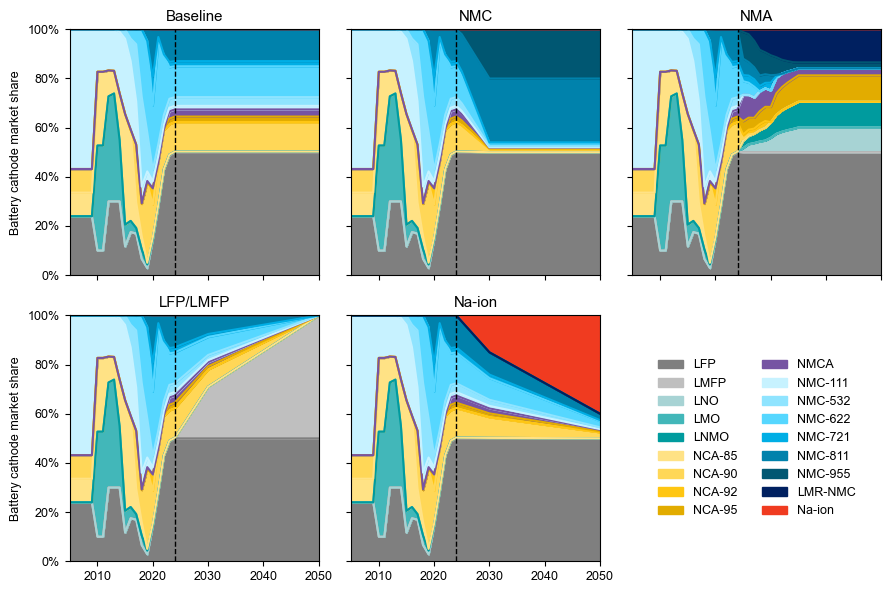

In [20]:
def plot_battery_cathode_share(df_share):
    
    year_min = 2005
    Old_Battery_Scenarios = ['Baseline', 'NMC', 'NMA', 'LFP/LMFP', 'Na-ion']
    
    # 2行3列，共6个子图
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), sharex=True, sharey=True)
    axes = axes.flatten()
    
    handles, labels = None, None
    
    # 前5个子图用于绘图
    for i, b_sce in enumerate(Old_Battery_Scenarios):
        ax = axes[i]
        
        df_share[b_sce].plot.area(
            ax=ax,
            y=Cathodes,
            color=Cathode_Colors,
            legend=False
        )
        
        ax.set_title(b_sce)
        ax.set_xlim(2005, 2050)
        ax.set_ylim(0, 1)
        ax.set_ylabel('Battery cathode market share')
        ax.set_xticks(np.arange(2010, 2051, 10))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
        ax.axvline(x=2024, color="black", linestyle="--", lw=1)
        # 只取一次 legend 信息
        if handles is None and labels is None:
            handles, labels = ax.get_legend_handles_labels()
    
    # 第6个子图不画图，只放 legend
    legend_ax = axes[-1]
    legend_ax.axis('off')
    legend_ax.legend(
        handles, labels,
        loc='center',
        ncol=2,   # 如果想横着排可以改成 ncol=2 / 3
        frameon=False
    )
    
    plt.tight_layout()
    plt.savefig(file_path + 'PEV_Battery_Cathode_Share.png',bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()


plot_battery_cathode_share(df_battery_share)

In [21]:
df_battery_lifetime = pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='Battery_Lifetime', index_col=[0], header=3)
df_battery_lifetime = df_battery_lifetime.T
df_battery_lifetime.head(2)

Scenario,Constant,Longer
2005,8.0,8.0
2006,8.0,8.0


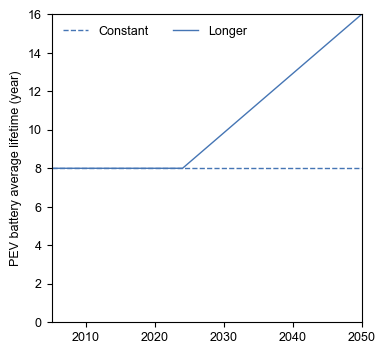

In [22]:
def plot_lifetime(df):
    year_min = 2005
    fig, ax = plt.subplots(1,1, figsize=(4,4))
    

    ax.plot(df.index, df['Constant'], label='Constant', color='#4575B4', lw=1, linestyle='--')
    ax.plot(df.index, df['Longer'], label='Longer', color='#4575B4', lw=1)
    
    ax.set_xlim(year_min,2050)
    ax.set_xticks(np.arange(2010,2051,10))
    ax.set_ylim(0,16)
    ax.set_ylabel('PEV battery average lifetime (year)')
    ax.legend(frameon=False, ncol=2)
    plt.savefig(file_path + 'PEV_Battery_Lifetime.png', bbox_inches='tight', pad_inches=.1, dpi=300)
    plt.show()
    
    
plot_lifetime(df_battery_lifetime)

In [23]:
%%time 

def cal_battery_stock_inflow_without_cathode(df_vehicle_s, df_capacity, df_share, df_lt):
    df_vehicle_s = df_vehicle_s.copy()
    df_vehicle_s = df_vehicle_s.loc[2005:,:]
    
    df_battery_s = pd.DataFrame(index=df_vehicle_s.index,
                              columns=pd.MultiIndex.from_product([Regions,Powertrain_Scenarios,EV_List,Segment_Scenarios,Segments,Lifetime_Scenarios,Battery_Sizes,Battery_Scenarios],
                                                                 names=['Region','Powertrain Scenario','Powertrain','Segment Scenario','Segment','Lifetime','Battery Size','Battery Scenario']))
    for r in Regions:
        for p_sce in Powertrain_Scenarios:
            for p in EV_List:
                for s_sce in Segment_Scenarios:
                    for s in Segments:
                        for lt in Lifetime_Scenarios:
                            for b_s in Battery_Sizes:
                                for b_sce in Battery_Scenarios:
                                    
                                    df_battery_s[(r,p_sce,p,s_sce,s,lt,b_s,b_sce)] = df_vehicle_s[(r,p_sce,p,s_sce,s,lt)] * df_capacity[(b_s,r,p,s)]
                                    

    df_battery_s = df_battery_s.T.groupby(['Region','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum().T
    df_battery_s = df_battery_s / 1e6  # unit: from kWh to GWh
    
    df_battery_i = df_battery_s.copy()
    
    ## Stock-driven 求 inflow
    for r in Regions:
        for p_sce in Powertrain_Scenarios:
                for s_sce in Segment_Scenarios:
                    for lt in Lifetime_Scenarios:
                        for b_s in Battery_Sizes:
                            for b_sce in Battery_Scenarios:
                                    
                                DSM = DynamicStockModel(t = list(df_battery_s.index), 
                                s = list(df_battery_s[(r,p_sce,s_sce,b_s,b_sce,lt)]), 
                                lt = {'Type': 'Normal',
                                      'Mean': list(df_lt[(lt)]),    
                                      'StdDev': list(0.3 * df_lt[(lt)])})
                                DSM.compute_stock_driven_model()
                                DSM.compute_outflow_total()
                                ## fill in
                                df_battery_i[(r,p_sce,s_sce,b_s,b_sce,lt)] = DSM.i
    
    return df_battery_s, df_battery_i
    
    
## Unit: GWh
df_battery_stock_without, df_battery_inflow_without = cal_battery_stock_inflow_without_cathode(df_vehicle_stock, df_battery_capacity, df_battery_share, df_battery_lifetime)
df_battery_stock_without.head(2)

CPU times: total: 1.45 s
Wall time: 1.47 s


Region                 China                                                  \
Powertrain Scenario      APS                                                   
Segment Scenario    Baseline                                                   
Battery Size          Larger                                                   
Battery Scenario    Baseline        LFP/LMFP             NMA             NMC   
Lifetime            Constant Longer Constant Longer Constant Longer Constant   
2005                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   
2006                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   

Region                                      ...       USA                      \
Powertrain Scenario                         ...     STEPS                       
Segment Scenario                            ...  Baseline                       
Battery Size                                ...    Larger                       
Battery Scenario             Na-ion         ...  LFP/LMFP                 NMA   
Lifetime            Longer Constant Longer  ...  Constant    Longer  Constant   
2005                   0.0      0.0    0.0  ...  0.046903  0.046903  0.046903   
2006                   0.0      0.0    0.0  ...  0.046882  0.046882  0.046882   

Region                                                                 \
Powertrain Scenario                                                     
Segment Scenario                                                        
Battery Size                                                            
Battery Scenario                    NMC              Na-ion             
Lifetime               Longer  Constant    Longer  Constant    Longer   
2005                 0.046903  0.046903  0.046903  0.046903  0.046903   
2006                 0.046882  0.046882  0.046882  0.046882  0.046882   

Region                                   
Powertrain Scenario                      
Segment Scenario                         
Battery Size                             
Battery Scenario    Optimized            
Lifetime             Constant    Longer  
2005                 0.046903  0.046903  
2006                 0.046882  0.046882  

[2 rows x 180 columns]

In [24]:
df_battery_inflow_without.head(2)

Region                 China                                                  \
Powertrain Scenario      APS                                                   
Segment Scenario    Baseline                                                   
Battery Size          Larger                                                   
Battery Scenario    Baseline        LFP/LMFP             NMA             NMC   
Lifetime            Constant Longer Constant Longer Constant Longer Constant   
2005                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   
2006                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   

Region                                      ...       USA                      \
Powertrain Scenario                         ...     STEPS                       
Segment Scenario                            ...  Baseline                       
Battery Size                                ...    Larger                       
Battery Scenario             Na-ion         ...  LFP/LMFP                 NMA   
Lifetime            Longer Constant Longer  ...  Constant    Longer  Constant   
2005                   0.0      0.0    0.0  ...  0.046923  0.046923  0.046923   
2006                   0.0      0.0    0.0  ...  0.000042  0.000042  0.000042   

Region                                                                 \
Powertrain Scenario                                                     
Segment Scenario                                                        
Battery Size                                                            
Battery Scenario                    NMC              Na-ion             
Lifetime               Longer  Constant    Longer  Constant    Longer   
2005                 0.046923  0.046923  0.046923  0.046923  0.046923   
2006                 0.000042  0.000042  0.000042  0.000042  0.000042   

Region                                   
Powertrain Scenario                      
Segment Scenario                         
Battery Size                             
Battery Scenario    Optimized            
Lifetime             Constant    Longer  
2005                 0.046923  0.046923  
2006                 0.000042  0.000042  

[2 rows x 180 columns]

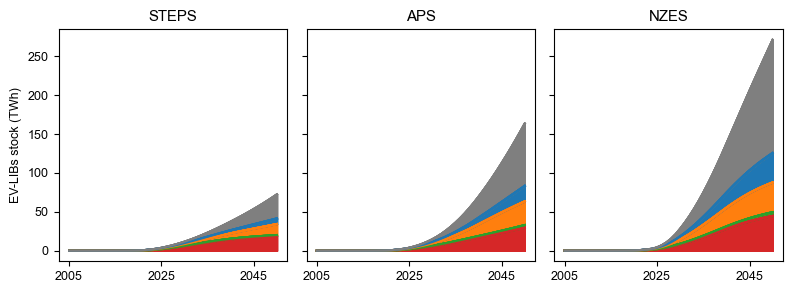

In [25]:
def plot_battery_stock_by_region(df):
    
    df = df / 1e3 # from GWh to TWh
    df = df.T
    df.reset_index(inplace=True, drop=False)
    df = df[df['Segment Scenario'] == 'Baseline']
    df = df[df['Battery Size'] == 'Larger']
    df = df[df['Lifetime'] == 'Constant']
    df = df.groupby(['Powertrain Scenario','Battery Scenario','Region']).sum(numeric_only=True).T
    
    fig, axes = plt.subplots(1, 3, figsize = (8, 3), sharey=True)
    
    b_sce = 'Baseline'
    for b_sce in Battery_Scenarios:
        for i, p_sce in enumerate(Powertrain_Scenarios):
            df_c = df[(p_sce,b_sce)]
            df_c.plot.area(ax=axes[i], y=Regions, color=Region_Colors, legend=False)
            
            #axes[i].set_xlim(2005,2050)
            axes[i].set_xlabel('')
            axes[i].set_ylabel('EV-LIBs stock (TWh)')
            axes[i].set_title(p_sce)
            
    plt.tight_layout()        
    plt.show()
            
        
plot_battery_stock_by_region(df_battery_stock_without)

In [26]:
%%time

def cal_battery_stock_flow_with_cathode(df_i_without, df_share, df_lt):
    
    df_i = pd.DataFrame(index=df_i_without.index,
                        columns=pd.MultiIndex.from_product([Regions,Powertrain_Scenarios,Segment_Scenarios,Battery_Sizes,Battery_Scenarios,Cathodes,Lifetime_Scenarios],
                                                           names=['Region','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Cathode','Lifetime']))
    df_o = df_i.copy()
    df_s = df_i.copy()
    
    for r in Regions:
        for p_sce in Powertrain_Scenarios:
            for s_sce in Segment_Scenarios:
                for b_s in Battery_Sizes:
                    for b_sce in Battery_Scenarios:
                        for c in Cathodes:
                            for lt in Lifetime_Scenarios:
                                
                                df_i[(r,p_sce,s_sce,b_s,b_sce,c,lt)] = df_i_without[(r,p_sce,s_sce,b_s,b_sce,lt)] * df_share[(b_sce,c)]
                                
                                ## inflow-driven
                                DSM = DynamicStockModel(t = list(df_i.index), 
                                i = list(df_i[(r,p_sce,s_sce,b_s,b_sce,c,lt)]), 
                                lt = {'Type': 'Normal',
                                      'Mean': list(df_lt[(lt)]),    
                                      'StdDev': list(0.3 * df_lt[(lt)])})
                                DSM.compute_s_c_inflow_driven()
                                DSM.compute_stock_total()
                                DSM.compute_o_c_from_s_c()
                                DSM.compute_outflow_total()
                                ## fill in
                                df_s[(r,p_sce,s_sce,b_s,b_sce,c,lt)] = DSM.s
                                df_o[(r,p_sce,s_sce,b_s,b_sce,c,lt)] = DSM.o
                                
    return df_i, df_o, df_s


## Unit: GWh
df_battery_inflow_cathode, df_battery_outflow_cathode, df_battery_stock_cathode = cal_battery_stock_flow_with_cathode(df_battery_inflow_without, df_battery_share, df_battery_lifetime)
df_battery_inflow_cathode.head(2)

CPU times: total: 14.6 s
Wall time: 15.1 s


Region                 China                                                  \
Powertrain Scenario    STEPS                                                   
Segment Scenario    Baseline                                                   
Battery Size          Larger                                                   
Battery Scenario    Baseline                                                   
Cathode                  LFP            LMFP             LNO             LMO   
Lifetime            Constant Longer Constant Longer Constant Longer Constant   
2005                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   
2006                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   

Region                                      ...       RoW                  \
Powertrain Scenario                         ...      NZES                   
Segment Scenario                            ...  Baseline                   
Battery Size                                ...    Larger                   
Battery Scenario                            ... Optimized                   
Cathode                        LNMO         ...   NMC-721         NMC-811   
Lifetime            Longer Constant Longer  ...  Constant Longer Constant   
2005                   0.0      0.0    0.0  ...       0.0    0.0      0.0   
2006                   0.0      0.0    0.0  ...       0.0    0.0      0.0   

Region                                                                      
Powertrain Scenario                                                         
Segment Scenario                                                            
Battery Size                                                                
Battery Scenario                                                            
Cathode                     NMC-955         LMR-NMC          Na-ion         
Lifetime            Longer Constant Longer Constant Longer Constant Longer  
2005                   0.0      0.0    0.0      0.0    0.0      0.0    0.0  
2006                   0.0      0.0    0.0      0.0    0.0      0.0    0.0  

[2 rows x 3240 columns]

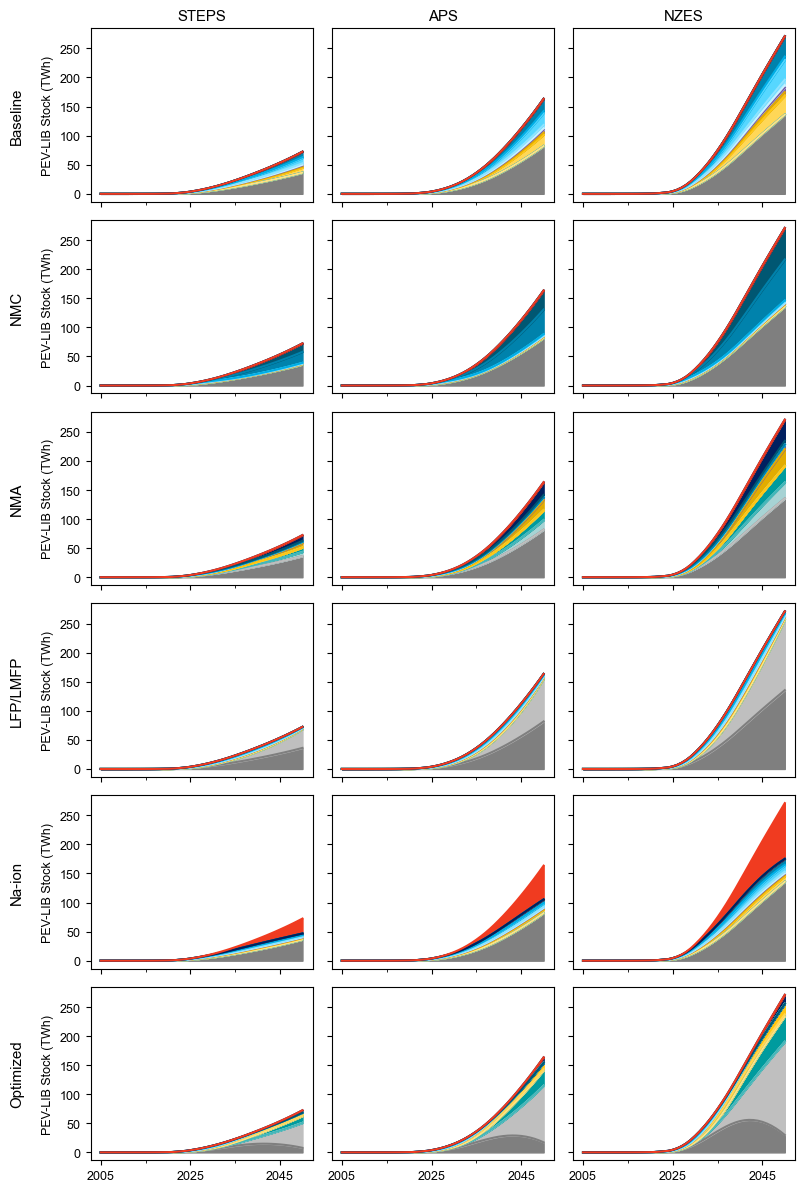

In [27]:
def plot_battery_inflow_by_cathode(df):
    
    df = df / 1e3 # from GWh to TWh
    df = df.T
    df.reset_index(inplace=True, drop=False)
    df = df[df['Segment Scenario'] == 'Baseline']
    df = df[df['Battery Size'] == 'Larger']
    df = df[df['Lifetime'] == 'Constant']
    df = df.groupby(['Powertrain Scenario','Battery Scenario','Cathode']).sum(numeric_only=True).T
    
    fig, axes = plt.subplots(len(Battery_Scenarios), len(Powertrain_Scenarios), figsize = (8, 12), sharex=True, sharey=True)
    
    for i, b_sce in enumerate(Battery_Scenarios):
        for j, p_sce in enumerate(Powertrain_Scenarios):
            
            df_c = df[(p_sce,b_sce)]
            df_c.plot.area(ax=axes[i,j], y=Cathodes, color=Cathode_Colors, legend=False)
            
            #axes[i,j].set_xlim(2005,2050)
            #axes[i,j].set_xticks(np.arange(2010,2051,10))            
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylabel('PEV-LIB Stock (TWh)')
            
            if i == 0:
                axes[i,j].set_title(p_sce)
            if j == 0:
                axes[i,j].annotate(b_sce, xy=(-0.3, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90) 
                
    plt.tight_layout()        
    plt.show()
        
        
plot_battery_inflow_by_cathode(df_battery_stock_cathode)

## Layer: Material
### Material in Battery
- material intensity (kg/kWh = kt/GW)

In [28]:
df_battery_intensity = pd.read_excel(file_path + 'Vehicle_compile_input_complex.xlsx', sheet_name='Battery_Material_intensity', index_col=[0,], header=3)
df_battery_intensity.fillna(value=0, inplace=True)
df_battery_intensity

,Copper,Nickel,Cobalt,Manganese
Cathodes,,,,
LFP,0.480,0.000,0.000,0.00
LMFP,0.480,0.000,0.000,0.31
LNO,0.279,0.780,0.000,0.00
LMO,0.450,0.000,0.000,1.27
LNMO,0.232,0.250,0.000,0.71
NCA-85,0.270,0.730,0.090,0.00
NCA-90,0.270,0.740,0.040,0.00
NCA-92,0.270,0.720,0.020,0.00
NCA-95,0.270,0.850,0.050,0.00


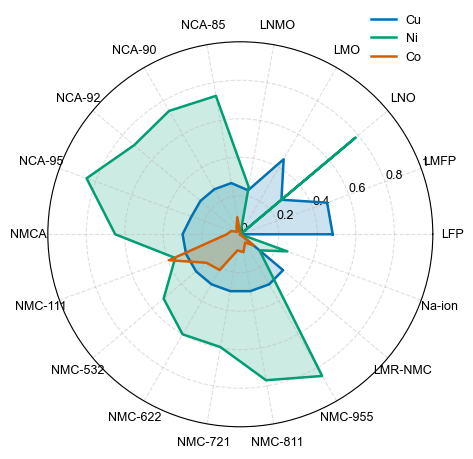

In [29]:
def plot_metal_radar(ax, angles, values, color, label, alpha=0.2, lw=1.8):
    # 闭合雷达图
    values = np.append(values, values[0])
    ax.plot(angles, values, color=color, linewidth=lw, label=label)
    ax.fill(angles, values, color=color, alpha=alpha)

# 1. 类别与角度
categories = df_battery_intensity.index.tolist()
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # 闭合

# 2. 自动设置径向范围与刻度
all_values = df_battery_intensity[['Copper', 'Nickel', 'Cobalt']].to_numpy().flatten()
rmax = all_values.max()

# 根据最大值自动选一个更自然的刻度间隔
if rmax <= 0.5:
    tick_step = 0.1
elif rmax <= 1:
    tick_step = 0.2
elif rmax <= 2:
    tick_step = 0.5
elif rmax <= 5:
    tick_step = 1
elif rmax <= 10:
    tick_step = 2
else:
    tick_step = 5

r_upper = np.ceil(rmax / tick_step) * tick_step
rticks = np.arange(0, r_upper + tick_step, tick_step)

# 3. 绘图
fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'polar': True})

plot_metal_radar(ax, angles, df_battery_intensity['Copper'].values, '#0072B2', 'Cu')
plot_metal_radar(ax, angles, df_battery_intensity['Nickel'].values, '#009E73', 'Ni')
plot_metal_radar(ax, angles, df_battery_intensity['Cobalt'].values, '#D55E00', 'Co')

# 4. 坐标轴设置
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

ax.set_ylim(0, r_upper)
ax.set_yticks(rticks)
ax.set_yticklabels([f"{x:g}" for x in rticks])

# 径向刻度标签位置
ax.set_rlabel_position(20)

# 网格线样式可选
ax.grid(True, linestyle='--', alpha=0.4)

# 图例
ax.legend(loc='upper right', bbox_to_anchor=(1, 1.1), frameon=False)
plt.savefig(file_path + 'Cathode_Mateiral_Intensity.png', bbox_inches='tight',  transparent=True, pad_inches=.1, dpi=300)
plt.savefig(file_path + 'Cathode_Mateiral_Intensity.svg', bbox_inches='tight', format='svg')
plt.show()

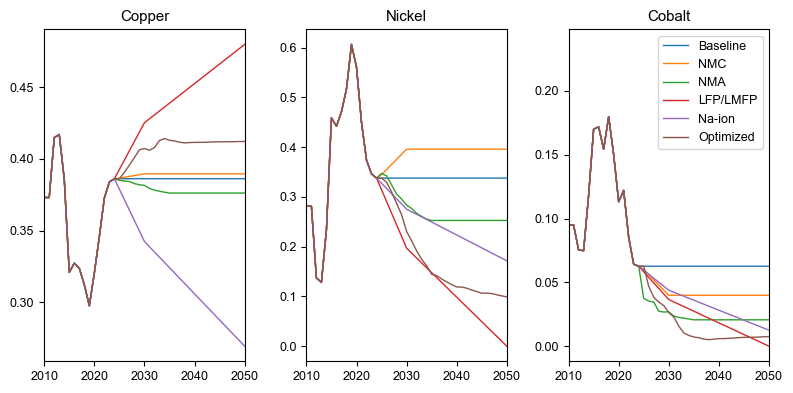

In [30]:
def plot_mix_intensity(df_battery, df_intensity):
    
    df_mix = pd.DataFrame(index=df_battery.index, 
                          columns=pd.MultiIndex.from_product([Materials, Battery_Scenarios, Cathodes], names=['Material', 'Battery Scenario', 'Cathode']))
    
    for m in Materials:
        for b_sce in Battery_Scenarios:
            for c in Cathodes:
                df_mix[(m,b_sce,c)] = df_battery[b_sce,c] * df_intensity.at[c,m]
                
    df_mix = df_mix.T.groupby(['Material','Battery Scenario']).sum().T
    
    fig, axes = plt.subplots(1,3, figsize=(8,4))
    
    for i, m in enumerate(Materials):
        
        axes[i].set_title(m)
        axes[i].set_xlim(2010,2050)
        
        for b_sce in Battery_Scenarios:
            axes[i].plot(df_mix.index, df_mix[m,b_sce], label=b_sce, lw=1)
        
    plt.legend()
    plt.tight_layout()
    plt.show()

    
plot_mix_intensity(df_battery_share, df_battery_intensity)

In [31]:
%%time

def cal_battery_material_stock_flow(df_battery_s, df_battery_i, df_battery_o, df_intensity, df_lt):
    idx = pd.IndexSlice

    df_material_i = pd.DataFrame(
        index=df_battery_i.index,
        columns=pd.MultiIndex.from_product(
            [Materials, Regions, Powertrain_Scenarios, Segment_Scenarios, Battery_Sizes,
             Battery_Scenarios, Cathodes, Lifetime_Scenarios],
            names=['Material','Region','Powertrain Scenario','Segment Scenario',
                   'Battery Size','Battery Scenario','Cathode','Lifetime']
        ),
        dtype="float64"   # <- 关键：避免 object
    )
    df_material_o = df_material_i.copy()
    df_material_s = df_material_i.copy()

    for m in Materials:
        for r in Regions:
            for p_sce in Powertrain_Scenarios:
                for s_sce in Segment_Scenarios:
                    for b_s in Battery_Sizes:
                        for b_sce in Battery_Scenarios:
                            for c in Cathodes:
                                for lt in Lifetime_Scenarios:
                                    df_material_i[(m,r,p_sce,s_sce,b_s,b_sce,c,lt)] = (
                                        df_battery_i[(r,p_sce,s_sce,b_s,b_sce,c,lt)] * df_intensity.at[c, m]
                                    )

    # ---- 关键修正：用 IndexSlice 精确选中 “Material= Cobalt” 的所有列，并 inplace 乘因子, 表示统计supply surplus造成的差异---- 
    cobalt_cols = idx['Cobalt', :, :, :, :, :, :, :]
    df_material_i.loc[2023, cobalt_cols] *= 1.35
    df_material_i.loc[2024, cobalt_cols] *= 1.20

    for m in Materials:
        for r in Regions:
            for p_sce in Powertrain_Scenarios:
                for s_sce in Segment_Scenarios:
                    for b_s in Battery_Sizes:
                        for b_sce in Battery_Scenarios:
                            for c in Cathodes:
                                for lt in Lifetime_Scenarios:
                                    DSM = DynamicStockModel(
                                        t=list(df_material_i.index),
                                        i=list(df_material_i[(m,r,p_sce,s_sce,b_s,b_sce,c,lt)]),
                                        lt={'Type': 'Normal',
                                            'Mean': list(df_lt[(lt)]),
                                            'StdDev': list(0.3 * df_lt[(lt)])}
                                    )
                                    DSM.compute_s_c_inflow_driven()
                                    DSM.compute_stock_total()
                                    DSM.compute_o_c_from_s_c()
                                    DSM.compute_outflow_total()

                                    df_material_o[(m,r,p_sce,s_sce,b_s,b_sce,c,lt)] = DSM.o
                                    df_material_s[(m,r,p_sce,s_sce,b_s,b_sce,c,lt)] = DSM.s

    return df_material_s, df_material_i, df_material_o

    
## Unit: kt                                  
df_battery_material_stock, df_battery_material_inflow, df_battery_material_outflow = cal_battery_material_stock_flow(df_battery_stock_cathode, df_battery_inflow_cathode, df_battery_outflow_cathode, df_battery_intensity, df_battery_lifetime)
df_battery_material_stock.head(2)

CPU times: total: 2min 48s
Wall time: 2min 55s


Material              Copper                                                  \
Region                 China                                                   
Powertrain Scenario    STEPS                                                   
Segment Scenario    Baseline                                                   
Battery Size          Larger                                                   
Battery Scenario    Baseline                                                   
Cathode                  LFP            LMFP             LNO             LMO   
Lifetime            Constant Longer Constant Longer Constant Longer Constant   
2005                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   
2006                     0.0    0.0      0.0    0.0      0.0    0.0      0.0   

Material                                    ...    Cobalt                  \
Region                                      ...       RoW                   
Powertrain Scenario                         ...      NZES                   
Segment Scenario                            ...  Baseline                   
Battery Size                                ...    Larger                   
Battery Scenario                            ... Optimized                   
Cathode                        LNMO         ...   NMC-721         NMC-811   
Lifetime            Longer Constant Longer  ...  Constant Longer Constant   
2005                   0.0      0.0    0.0  ...       0.0    0.0      0.0   
2006                   0.0      0.0    0.0  ...       0.0    0.0      0.0   

Material                                                                    
Region                                                                      
Powertrain Scenario                                                         
Segment Scenario                                                            
Battery Size                                                                
Battery Scenario                                                            
Cathode                     NMC-955         LMR-NMC          Na-ion         
Lifetime            Longer Constant Longer Constant Longer Constant Longer  
2005                   0.0      0.0    0.0      0.0    0.0      0.0    0.0  
2006                   0.0      0.0    0.0      0.0    0.0      0.0    0.0  

[2 rows x 9720 columns]

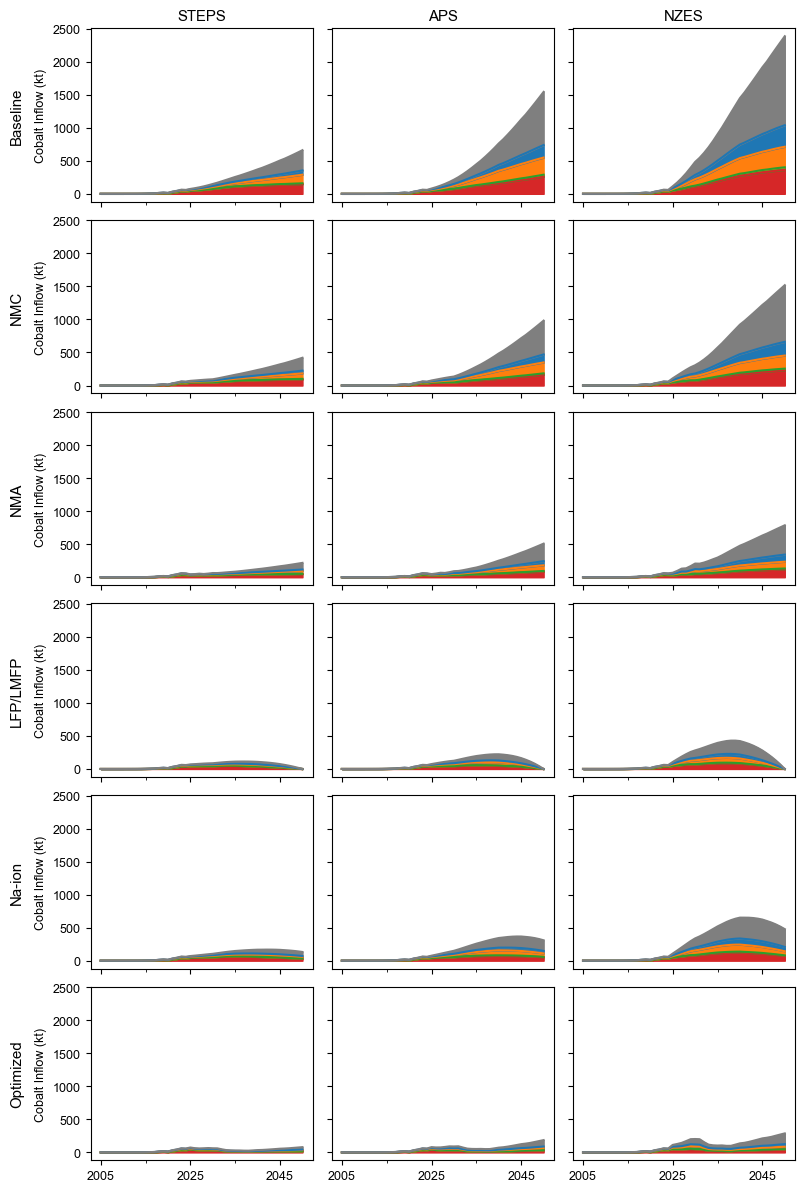

In [32]:
def plot_battery_material_by_region(df, material):
    
    df = df.T
    df.reset_index(inplace=True, drop=False)
    df = df[df['Material'] == material]
    df = df[df['Segment Scenario'] == 'Baseline']
    df = df[df['Battery Size'] == 'Larger']
    df = df[df['Lifetime'] == 'Constant']
    df = df.groupby(['Powertrain Scenario','Battery Scenario','Region']).sum(numeric_only=True).T
    
    fig, axes = plt.subplots(len(Battery_Scenarios), len(Powertrain_Scenarios), figsize = (8, 12), sharex=True, sharey=True)
    
    for i, b_sce in enumerate(Battery_Scenarios):
        for j, p_sce in enumerate(Powertrain_Scenarios):
            df_c = df[(p_sce,b_sce)]
            df_c.plot.area(ax=axes[i,j], y=Regions, color=Region_Colors, legend=False)
            
            #axes[i,j].set_xlim(2005,2050)
            #axes[i,j].axvline(2022, color='k', linestyle='--', lw=1)
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylabel(material + ' Inflow (kt)')
            
            if i == 0:
                axes[i,j].set_title(p_sce)
            if j == 0:
                axes[i,j].annotate(b_sce, xy=(-0.3, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
            
    plt.tight_layout()        
    plt.show()
    
    
plot_battery_material_by_region(df_battery_material_inflow, 'Cobalt')

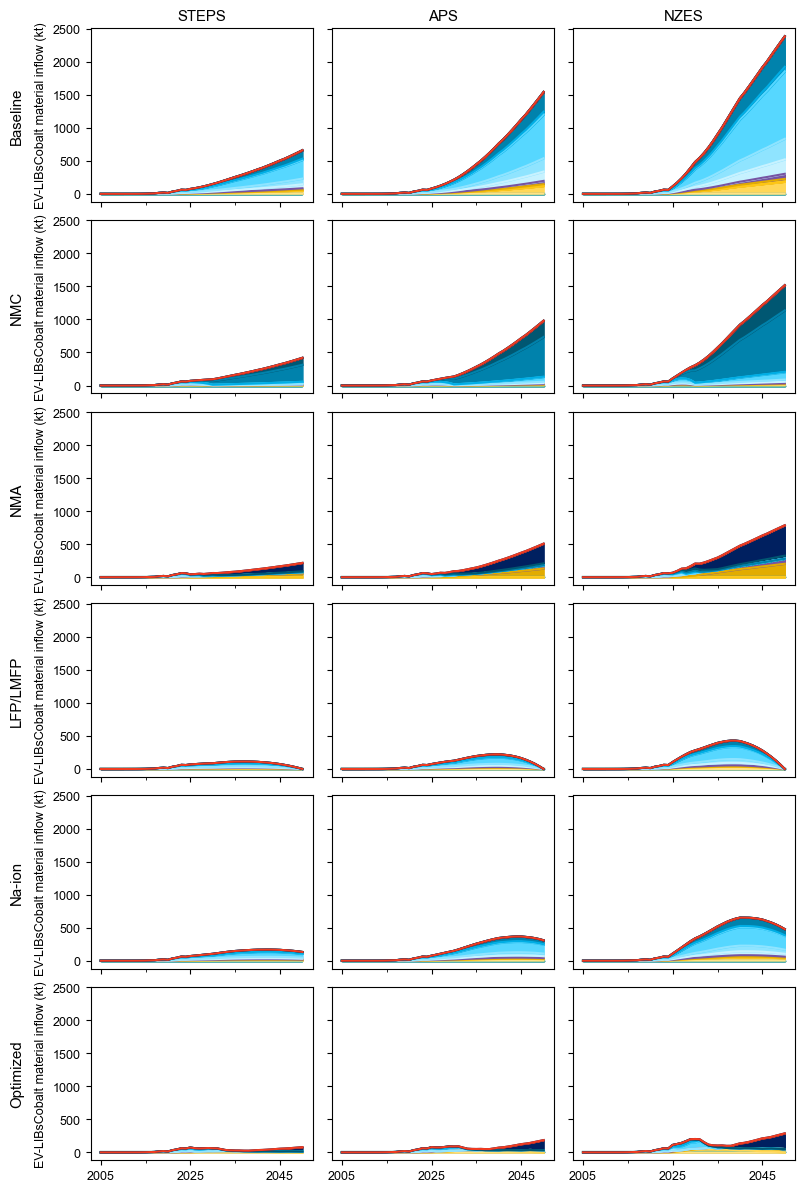

In [33]:
def plot_battery_material_by_cathode(df, material):
    
    ## World
    df = df.T
    df.reset_index(inplace=True, drop=False)
    df = df[df['Material'] == material]
    df = df[df['Segment Scenario'] == 'Baseline']
    df = df[df['Battery Size'] == 'Larger']
    df = df[df['Lifetime'] == 'Constant']
    df = df.groupby(['Powertrain Scenario','Battery Scenario','Cathode']).sum(numeric_only=True).T
    
    fig, axes = plt.subplots(len(Battery_Scenarios), len(Powertrain_Scenarios), figsize = (8, 12), sharex=True, sharey=True)
    
    for i, b_sce in enumerate(Battery_Scenarios):
        for j, p_sce in enumerate(Powertrain_Scenarios):
            
            df_c = df[(p_sce,b_sce)]
            df_c.plot.area(ax=axes[i,j], y=Cathodes, color=Cathode_Colors, legend=False)
            
            #axes[i,j].set_xlim(2020,2050)
            #axes[i,j].axvline(2022, color='k', linestyle='--', lw=1)
            axes[i,j].set_xlabel('')
            axes[i,j].set_ylabel('EV-LIBs'+ material + ' material inflow (kt)')
            
            if i == 0:
                axes[i,j].set_title(p_sce)
            if j == 0:
                axes[i,j].annotate(b_sce, xy=(-0.3, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
            
    plt.tight_layout()        
    plt.show()
    
    
plot_battery_material_by_cathode(df_battery_material_inflow, 'Cobalt')

## Export data

In [34]:
%%time

with pd.ExcelWriter(file_path + 'Vehicle_Output.xlsx') as writer:
    
    ## Vehicle
    df_vehicle_stock.T.to_excel(excel_writer = writer, sheet_name='vehicle_stock')
    df_vehicle_inflow.T.to_excel(excel_writer = writer, sheet_name='vehicle_inflow')
    df_vehicle_outflow.T.to_excel(excel_writer = writer, sheet_name='vehicle_outflow')
    
    ## Battery: GWh
    df_battery_stock_cathode.T.to_excel(excel_writer = writer, sheet_name='battery_stock')
    df_battery_inflow_cathode.T.to_excel(excel_writer = writer, sheet_name='battery_inflow')
    df_battery_outflow_cathode.T.to_excel(excel_writer = writer, sheet_name='battery_outflow')
    
    ## Material: kt
    df_battery_material_stock.T.to_excel(excel_writer = writer, sheet_name='battery_material_stock')
    df_battery_material_inflow.T.to_excel(excel_writer = writer, sheet_name='battery_material_inflow')
    df_battery_material_outflow.T.to_excel(excel_writer = writer, sheet_name='battery_material_outflow')

CPU times: total: 2min 20s
Wall time: 2min 26s


In [35]:
def filter_df_vehicle(df):
    
    df = df.T
    df.reset_index(inplace=True, drop=False)
    
    df = df[df['Powertrain Scenario'] == 'APS']
    df = df[df['Segment Scenario'] == 'Baseline']
    df = df[df['Lifetime'] == 'Constant']

    df = df.groupby(['Region','Powertrain']).sum(numeric_only=True)
    df.reset_index(inplace=True, drop=False)
    
    return df


def filter_df_battery(df):
    
    df = df.T
    df.reset_index(inplace=True, drop=False)
    
    df = df[df['Powertrain Scenario'] == 'APS']
    df = df[df['Segment Scenario'] == 'Baseline']
    df = df[df['Battery Size'] == 'Larger']
    df = df[df['Battery Scenario'] == 'Baseline']
    df = df[df['Lifetime'] == 'Constant']

    df = df.groupby(['Region']).sum(numeric_only=True)
    df.reset_index(inplace=True, drop=False)
    
    return df


def filter_df_battery_material(df):
    
    df = df.T
    df.reset_index(inplace=True, drop=False)
    
    df = df[df['Powertrain Scenario'] == 'APS']
    df = df[df['Segment Scenario'] == 'Baseline']
    df = df[df['Battery Size'] == 'Larger']
    df = df[df['Battery Scenario'] == 'Baseline']
    df = df[df['Lifetime'] == 'Constant']

    df = df.groupby(['Material','Region']).sum(numeric_only=True)
    df.reset_index(inplace=True, drop=False)
    
    return df


with pd.ExcelWriter(file_path + 'Vehicle_Output_filter.xlsx') as writer:
    
    ## Vehicle
    filter_df_vehicle(df_vehicle_stock).to_excel(excel_writer = writer, sheet_name='vehicle_stock')
    filter_df_vehicle(df_vehicle_inflow).to_excel(excel_writer = writer, sheet_name='vehicle_inflow')
    filter_df_vehicle(df_vehicle_outflow).to_excel(excel_writer = writer, sheet_name='vehicle_outflow')
    
    ## Battery: GWh
    filter_df_battery(df_battery_stock_cathode).to_excel(excel_writer = writer, sheet_name='battery_stock')
    filter_df_battery(df_battery_inflow_cathode).to_excel(excel_writer = writer, sheet_name='battery_inflow')
    filter_df_battery(df_battery_outflow_cathode).to_excel(excel_writer = writer, sheet_name='battery_outflow')
    
    ## Material: kt
    filter_df_battery_material(df_battery_material_stock).to_excel(excel_writer = writer, sheet_name='battery_material_stock')
    filter_df_battery_material(df_battery_material_inflow).to_excel(excel_writer = writer, sheet_name='battery_material_inflow')
    filter_df_battery_material(df_battery_material_outflow).to_excel(excel_writer = writer, sheet_name='battery_material_outflow')

In [36]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 6分钟 22秒
